# Análisis univariado

Este notebook examina cada variable del dataset **AI Dependency, Career Anxiety and Student Burnout** de forma independiente. El objetivo es caracterizar la distribución de cada variable antes de avanzar hacia análisis relacionales.

El análisis cubre variables numéricas y categóricas. Para las primeras se calculan estadísticas descriptivas, se identifican valores atípicos y se describe la forma de la distribución. Para las segundas se describe la frecuencia de cada categoría. En ambos casos se generan gráficos individuales que quedan disponibles en `outputs/graficos/`.

## 1. Configuración y carga de datos

Se cargan las librerías principales y el dataset limpio generado en la etapa de calidad de datos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "dataset_limpio.csv").exists():
    PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_limpio.csv"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tablas"
OUTPUT_GRAFICOS_DIR = PROJECT_ROOT / "outputs" / "graficos"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_GRAFICOS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

display(Markdown(f"Dataset cargado desde `{DATA_PATH}`."))
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.head()

Dataset cargado desde `d:\Documentos(D)\U\Progra\proyecto-ingenieria-datos\data\processed\dataset_limpio.csv`.

Filas: 11,119
Columnas: 30


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


## 2. Clasificación de variables

Se separan variables numéricas y categóricas porque requieren técnicas distintas. `student_id` se excluye porque es un identificador sin valor analítico.

In [2]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c != "student_id"]
cat_cols = [c for c in df.select_dtypes(exclude="number").columns if c != "student_id"]

display(Markdown(f"**Variables numéricas ({len(num_cols)}):**"))
display(pd.DataFrame({"variable": num_cols}))

display(Markdown(f"**Variables categóricas ({len(cat_cols)}):**"))
display(pd.DataFrame({"variable": cat_cols}))

**Variables numéricas (22):**

,variable
0,age
1,year_of_study
2,daily_ai_tool_usage_hrs
3,ai_replaces_own_thinking_score
4,ai_dependency_score
5,placement_anxiety_score
6,fear_of_job_loss_to_ai
7,career_clarity_score
8,internship_experience
9,weekly_job_application_count


**Variables categóricas (7):**

,variable
0,gender
1,degree_type
2,stream
3,college_tier
4,urban_or_rural
5,primary_ai_tools_used
6,uses_ai_for_assignments


## 3. Estadísticas descriptivas — variables numéricas

Se calculan media, mediana, mínimo, máximo y desviación estándar para cada variable numérica. Se añaden los percentiles 25, 75 y 90 para describir mejor la dispersión y detectar asimetrías sin depender exclusivamente de la media.

In [3]:
stats = df[num_cols].agg(["mean", "median", "min", "max", "std"]).T
stats.columns = ["Media", "Mediana", "Mínimo", "Máximo", "Desv_std"]
for p in [25, 75, 90]:
    stats[f"P{p}"] = df[num_cols].quantile(p / 100)
stats.index.name = "Variable"
stats = stats.reset_index().round(3)

stats.to_csv(OUTPUT_TABLES_DIR / "estadisticas_descriptivas.csv", index=False)
display(Markdown(f"Tabla guardada en `outputs/tablas/estadisticas_descriptivas.csv`."))
display(stats.set_index("Variable"))

Tabla guardada en `outputs/tablas/estadisticas_descriptivas.csv`.

,Media,Mediana,Mínimo,Máximo,Desv_std,P25,P75,P90
Variable,,,,,,,,
age,21.388,21.00,18.0,28.0,2.015,20.00,22.00,24.00
year_of_study,2.106,2.00,1.0,4.0,0.993,1.00,3.00,4.00
daily_ai_tool_usage_hrs,2.568,2.40,0.2,8.0,1.566,1.30,3.55,4.80
ai_replaces_own_thinking_score,3.227,3.00,1.0,5.0,1.274,2.00,4.00,5.00
ai_dependency_score,5.061,5.00,1.0,10.0,2.244,3.00,7.00,8.00
placement_anxiety_score,5.958,6.00,1.0,10.0,2.553,4.00,8.00,9.00
fear_of_job_loss_to_ai,3.651,4.00,1.0,5.0,1.164,3.00,5.00,5.00
career_clarity_score,5.088,5.00,1.0,10.0,2.199,4.00,7.00,8.00
internship_experience,1.717,2.00,0.0,4.0,1.068,1.00,2.00,3.00


## 4. Detección de valores atípicos

Se aplica la regla de Tukey: un valor se considera atípico si está fuera del intervalo [Q1 − 1,5·IQR, Q3 + 1,5·IQR]. Este criterio es robusto frente a distribuciones asimétricas y no supone normalidad.

La tabla resultante indica, para cada variable, los límites del intervalo esperado, la cantidad de observaciones fuera de él y el porcentaje que representan sobre el total.

In [4]:
records = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())
    records.append({
        "Variable": col,
        "Límite inf.": round(lo, 3),
        "Límite sup.": round(hi, 3),
        "N outliers": n_out,
        "% outliers": round(n_out / len(df) * 100, 2),
    })

outliers_df = pd.DataFrame(records)
outliers_df.to_csv(OUTPUT_TABLES_DIR / "reporte_outliers.csv", index=False)
display(Markdown("Tabla guardada en `outputs/tablas/reporte_outliers.csv`."))
display(outliers_df.set_index("Variable"))

Tabla guardada en `outputs/tablas/reporte_outliers.csv`.

,Límite inf.,Límite sup.,N outliers,% outliers
Variable,,,,
age,17.000,25.000,451,4.06
year_of_study,-2.000,6.000,0,0.00
daily_ai_tool_usage_hrs,-2.075,6.925,88,0.79
ai_replaces_own_thinking_score,-1.000,7.000,0,0.00
ai_dependency_score,-3.000,13.000,0,0.00
placement_anxiety_score,-2.000,14.000,0,0.00
fear_of_job_loss_to_ai,0.000,8.000,0,0.00
career_clarity_score,-0.500,11.500,0,0.00
internship_experience,-0.500,3.500,583,5.24


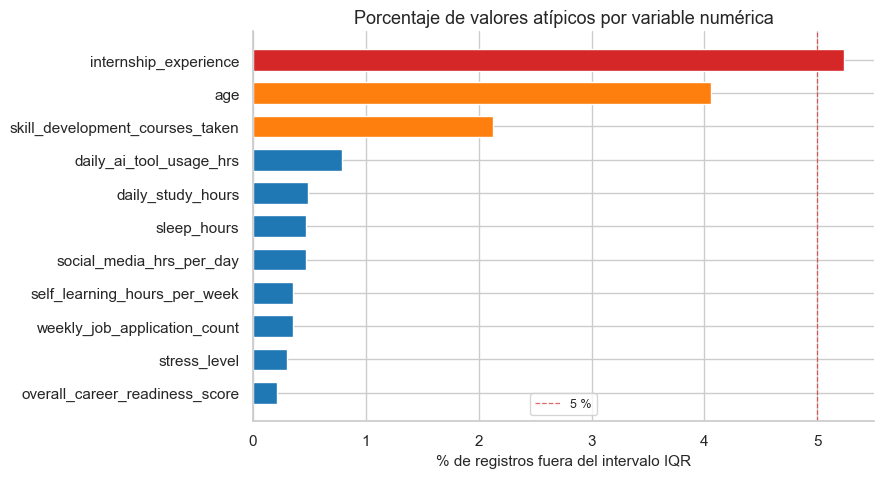

In [5]:
con_outliers = outliers_df[outliers_df["N outliers"] > 0].sort_values("% outliers", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(3, len(con_outliers) * 0.45)))
colors = ["#d62728" if v > 5 else "#ff7f0e" if v > 1 else "#1f77b4"
          for v in con_outliers["% outliers"]]
ax.barh(con_outliers["Variable"], con_outliers["% outliers"], color=colors, edgecolor="white", height=0.65)
ax.axvline(5, color="#d62728", linestyle="--", linewidth=0.9, alpha=0.7, label="5 %")
ax.set_xlabel("% de registros fuera del intervalo IQR")
ax.set_title("Porcentaje de valores atípicos por variable numérica")
ax.legend(fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_GRAFICOS_DIR / "resumen_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Variables con baja variabilidad

Una variable con baja variabilidad aporta poca información discriminativa. Para variables numéricas se evalúa el coeficiente de variación (CV = desviación estándar / media); valores menores a 0,05 sugieren poca dispersión relativa. Para variables categóricas se verifica si una categoría concentra más del 95 % de los registros.

In [6]:
low_var = []

for col in num_cols:
    mean_val = df[col].mean()
    cv = df[col].std() / mean_val if mean_val != 0 else np.inf
    if cv < 0.05:
        low_var.append({"Variable": col, "Tipo": "numérica", "Motivo": f"CV = {cv:.4f}"})

for col in cat_cols:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        low_var.append({"Variable": col, "Tipo": "categórica", "Motivo": f"Categoría dominante = {top_freq:.2%}"})

low_var_df = pd.DataFrame(low_var) if low_var else pd.DataFrame(columns=["Variable", "Tipo", "Motivo"])
low_var_df.to_csv(OUTPUT_TABLES_DIR / "baja_variabilidad.csv", index=False)

if low_var_df.empty:
    display(Markdown("No se detectaron variables con baja variabilidad."))
else:
    display(Markdown(f"**Variables con baja variabilidad detectadas:** {len(low_var_df)}"))
    display(low_var_df)

No se detectaron variables con baja variabilidad.

## 6. Distribuciones de variables numéricas

Para cada variable numérica se genera un histograma con estimación de densidad y un boxplot. El histograma permite observar la forma general de la distribución; el boxplot visualiza la mediana, el rango intercuartílico y los valores atípicos. Ambos gráficos se guardan en `outputs/graficos/`.

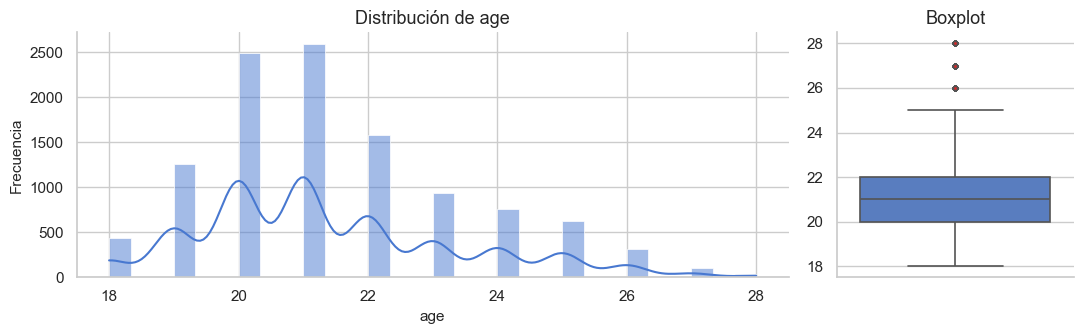

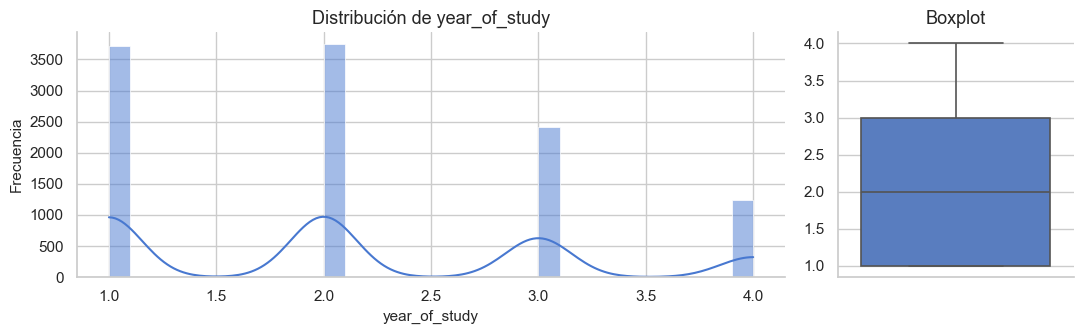

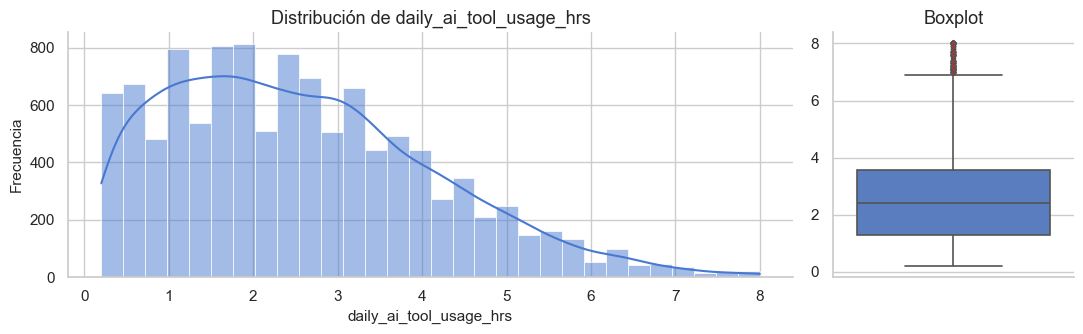

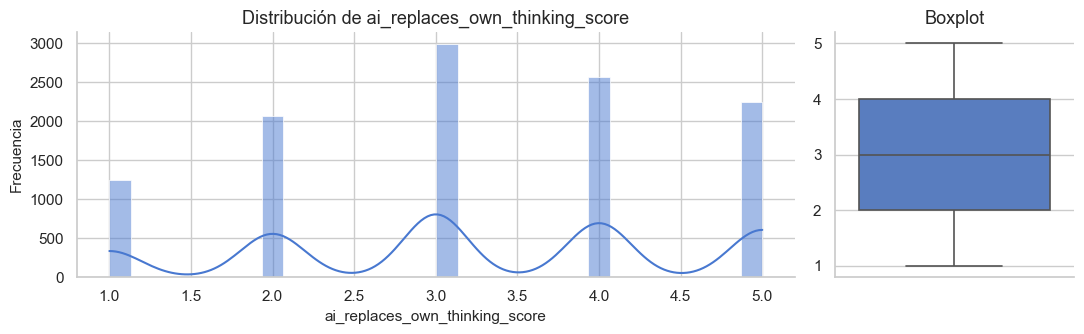

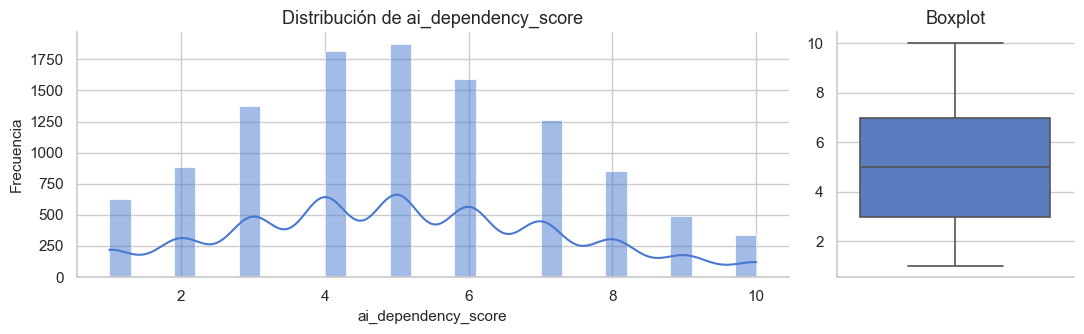

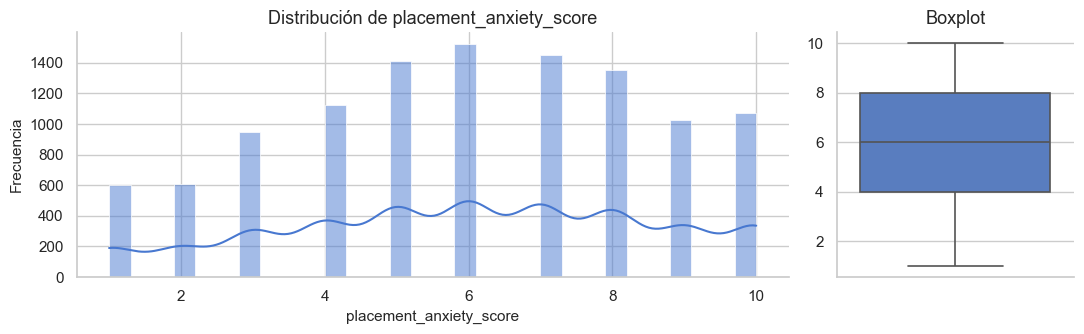

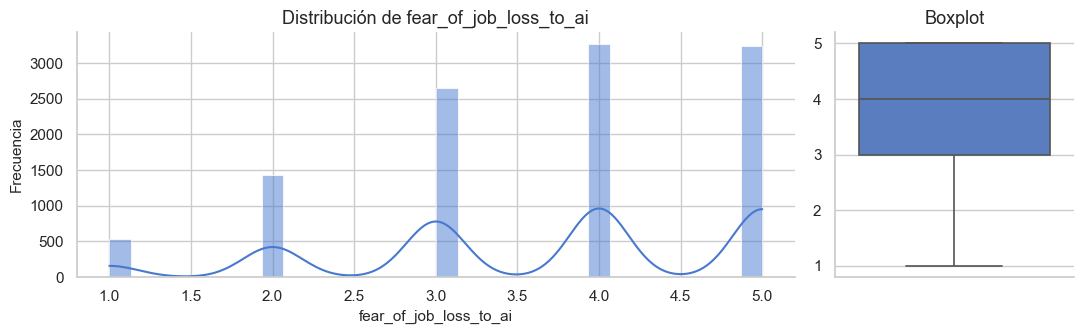

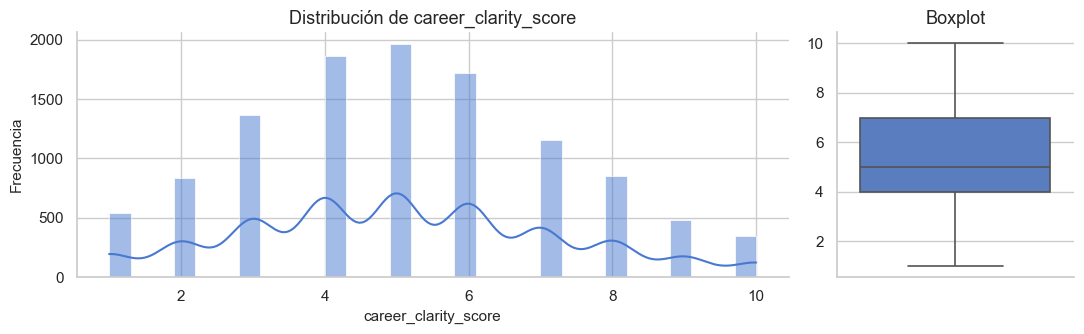

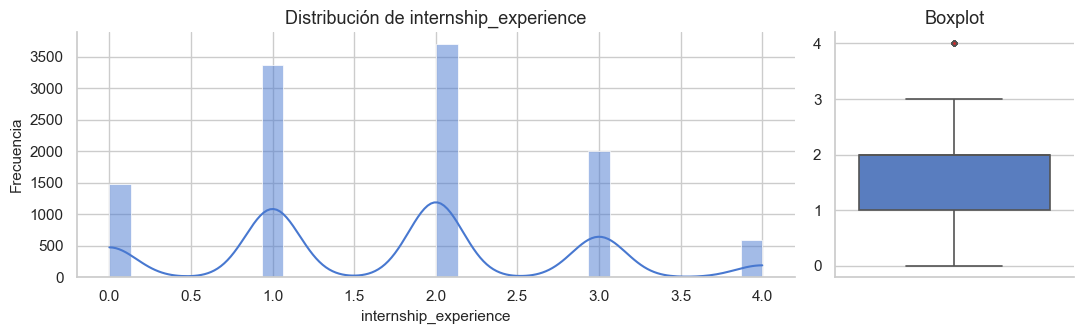

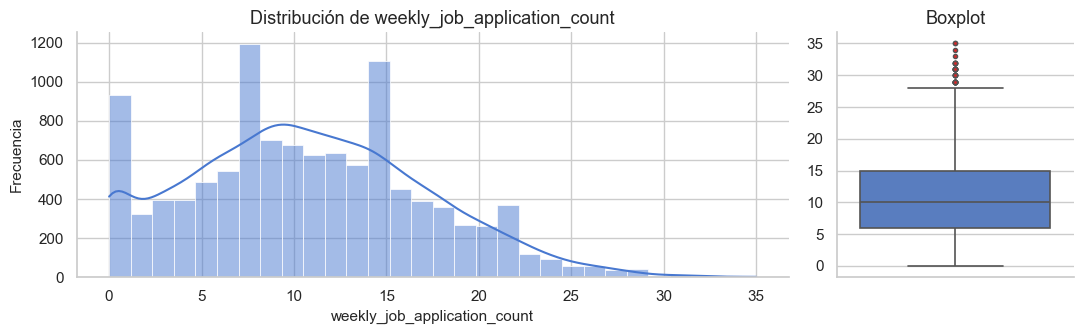

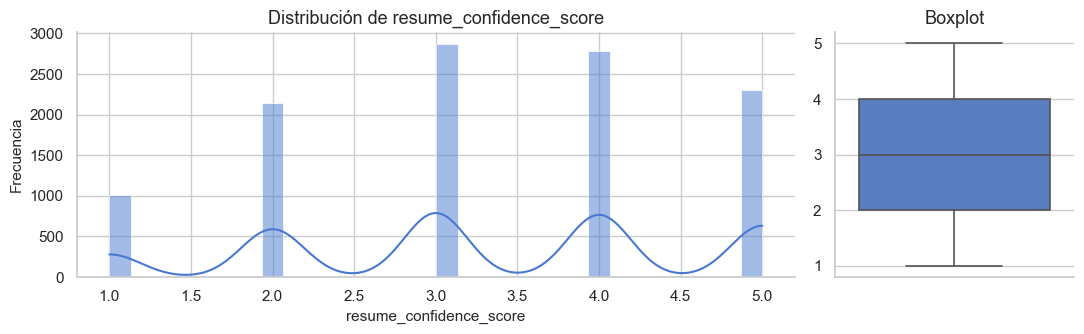

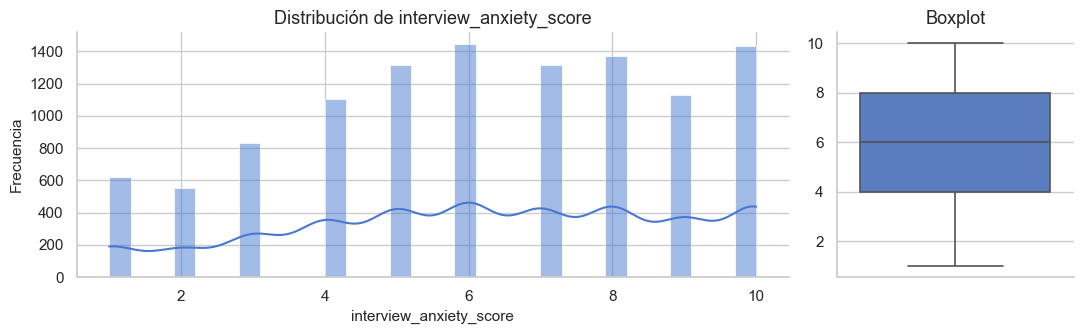

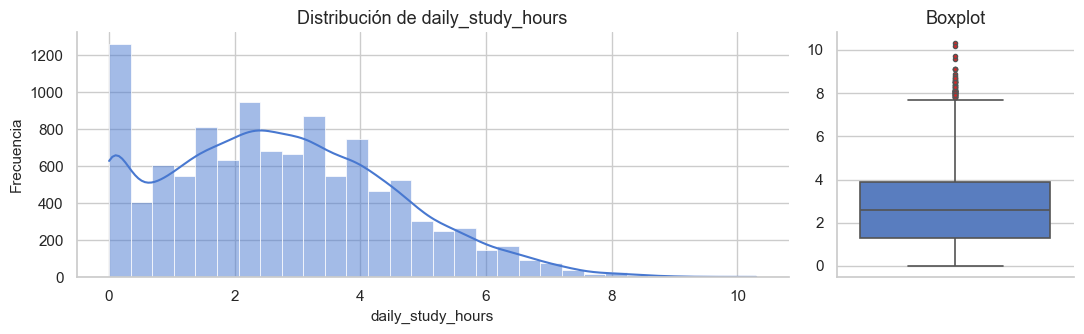

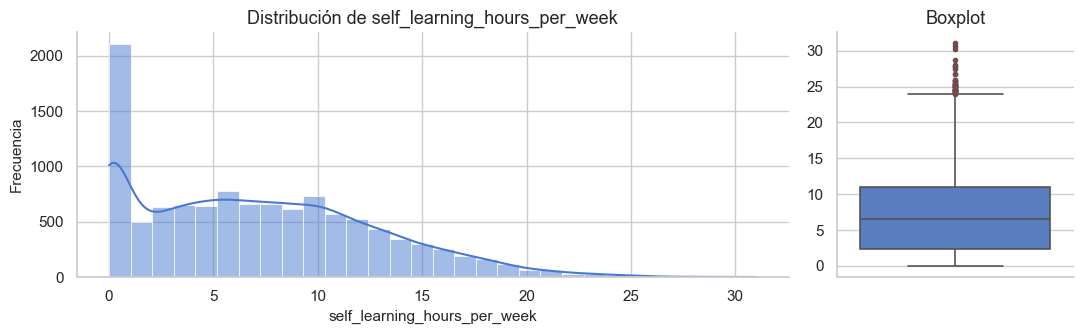

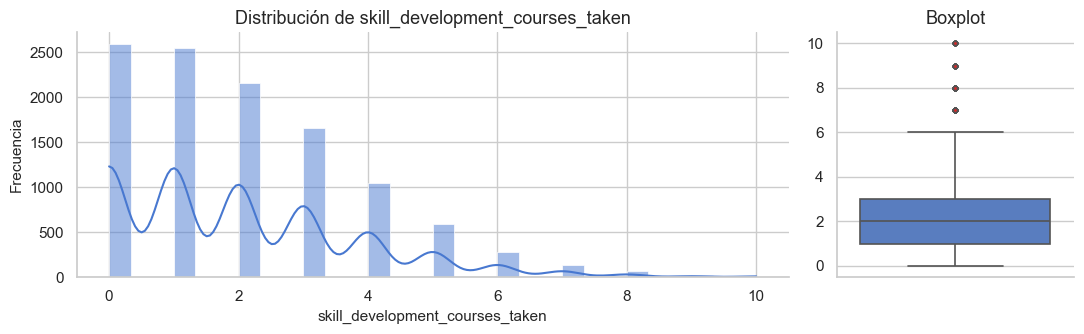

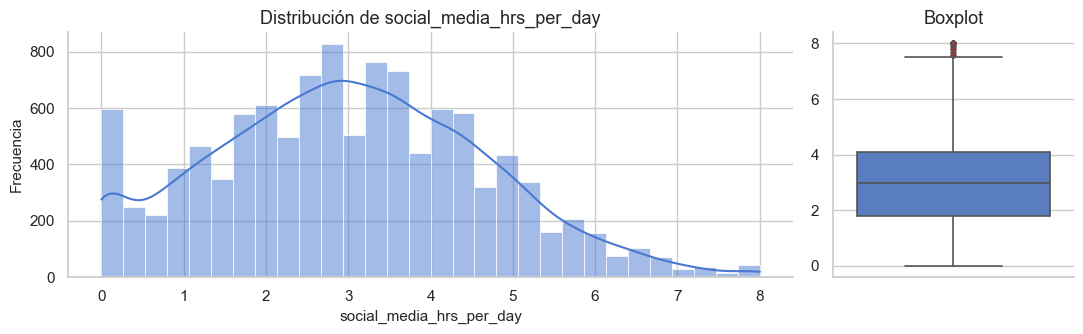

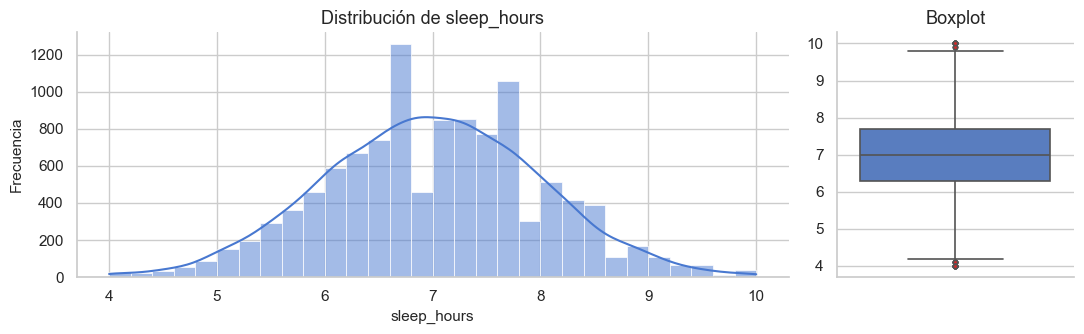

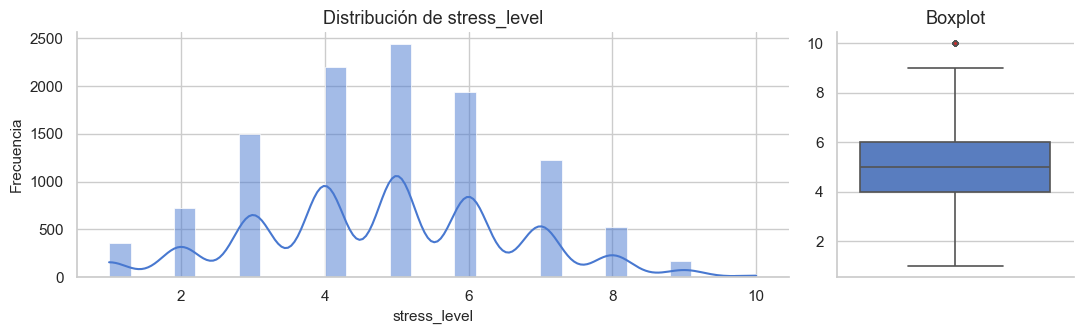

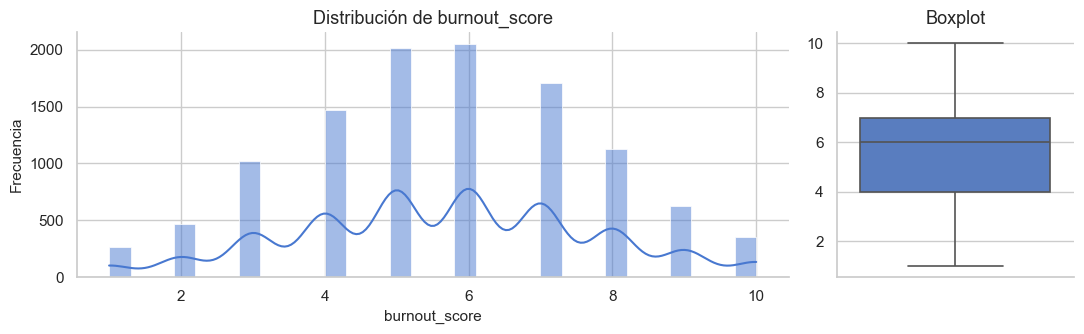

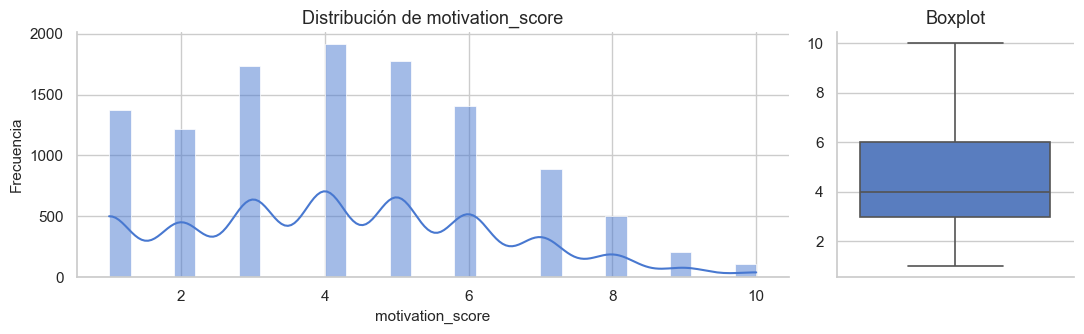

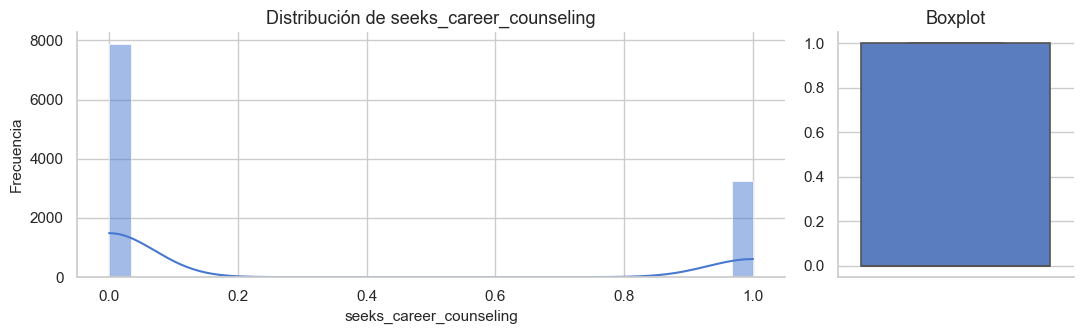

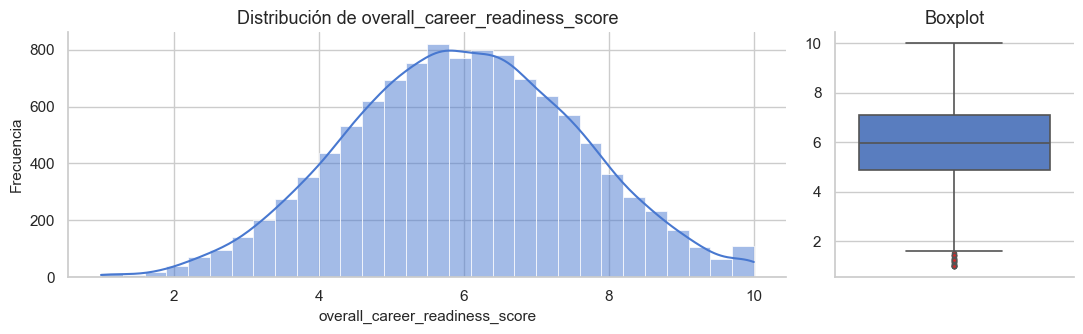

22 gráficos guardados en `outputs/graficos/`.

In [7]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5),
                             gridspec_kw={"width_ratios": [3, 1]})

    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[0],
                 color="#4878d0", edgecolor="white", linewidth=0.5)
    axes[0].set_title(f"Distribución de {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(y=df[col].dropna(), ax=axes[1], color="#4878d0",
                linewidth=1.2,
                flierprops=dict(marker="o", markerfacecolor="#d62728", markersize=3))
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("")

    sns.despine(fig=fig)
    fig.tight_layout()
    fig.savefig(OUTPUT_GRAFICOS_DIR / f"univar_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()

display(Markdown(f"{len(num_cols)} gráficos guardados en `outputs/graficos/`."))

## 7. Distribuciones de variables categóricas

Para cada variable categórica se genera un gráfico de barras que muestra la frecuencia absoluta y el porcentaje de cada categoría. Este tipo de gráfico es más adecuado que un histograma cuando los valores son discretos y no ordenables de forma continua.

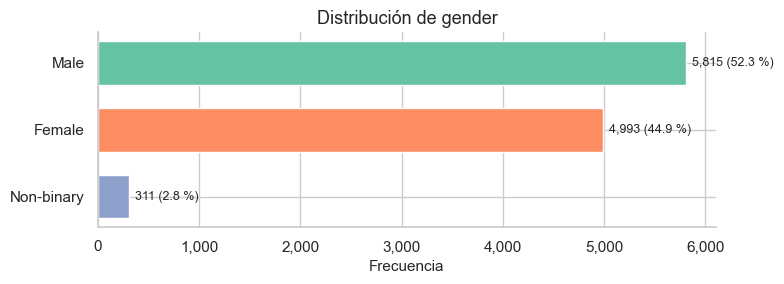

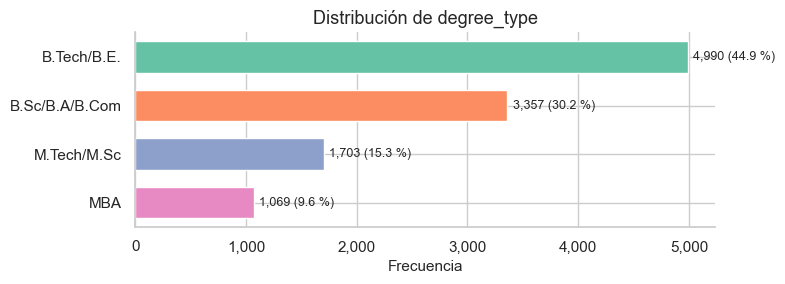

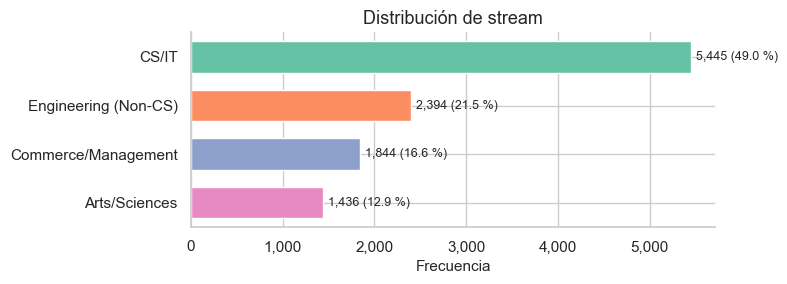

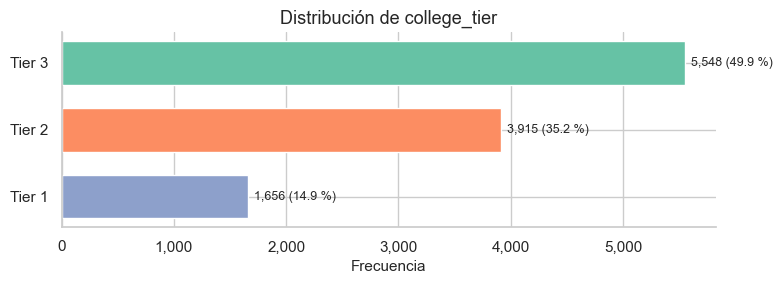

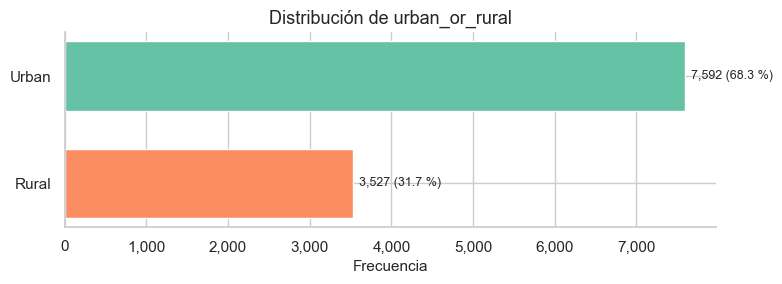

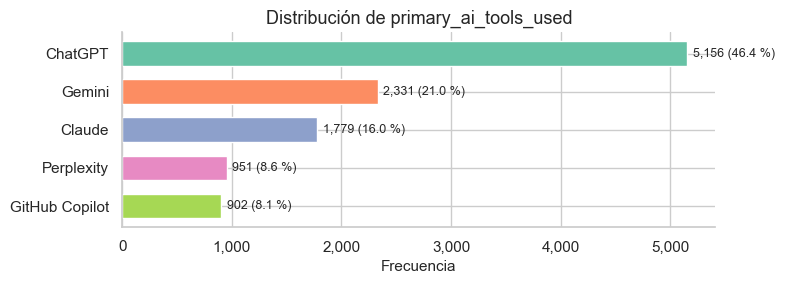

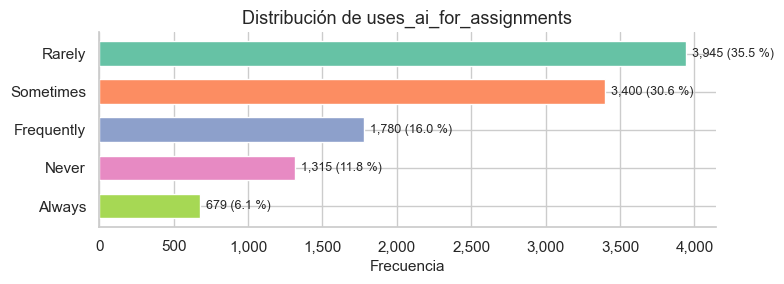

7 gráficos guardados en `outputs/graficos/`.

In [8]:
for col in cat_cols:
    counts = df[col].value_counts()
    palette = sns.color_palette("Set2", n_colors=len(counts))

    fig, ax = plt.subplots(figsize=(8, max(3, len(counts) * 0.55)))
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=palette[::-1], edgecolor="white", height=0.65)
    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + counts.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,} ({val / len(df) * 100:.1f} %)",
                va="center", fontsize=9)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("Frecuencia")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    sns.despine(ax=ax)
    fig.tight_layout()
    fig.savefig(OUTPUT_GRAFICOS_DIR / f"bar_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()

display(Markdown(f"{len(cat_cols)} gráficos guardados en `outputs/graficos/`."))

## 8. Forma de las distribuciones

Se calcula la asimetría y la curtosis de cada variable numérica para complementar la inspección visual. Una asimetría próxima a 0 indica distribución simétrica; valores positivos señalan cola derecha y negativos cola izquierda. La curtosis mide el peso de las colas respecto a una distribución normal (curtosis = 0 bajo la convención de exceso).

In [9]:
shape_df = pd.DataFrame({
    "Asimetría": df[num_cols].skew(),
    "Curtosis":  df[num_cols].kurtosis(),
}).reset_index().rename(columns={"index": "Variable"})

shape_df["Forma"] = shape_df["Asimetría"].apply(
    lambda s: "Sesgo derecho" if s > 0.5 else ("Sesgo izquierdo" if s < -0.5 else "Aproximadamente simétrica")
)

shape_df.to_csv(OUTPUT_TABLES_DIR / "forma_distribuciones.csv", index=False)
display(Markdown("Tabla guardada en `outputs/tablas/forma_distribuciones.csv`."))
display(shape_df.set_index("Variable").round(3))

Tabla guardada en `outputs/tablas/forma_distribuciones.csv`.

,Asimetría,Curtosis,Forma
Variable,,,
age,0.723,0.107,Sesgo derecho
year_of_study,0.470,-0.868,Aproximadamente simétrica
daily_ai_tool_usage_hrs,0.643,-0.040,Sesgo derecho
ai_replaces_own_thinking_score,-0.168,-1.003,Aproximadamente simétrica
ai_dependency_score,0.179,-0.589,Aproximadamente simétrica
placement_anxiety_score,-0.179,-0.876,Aproximadamente simétrica
fear_of_job_loss_to_ai,-0.516,-0.636,Sesgo izquierdo
career_clarity_score,0.200,-0.510,Aproximadamente simétrica
internship_experience,0.189,-0.587,Aproximadamente simétrica


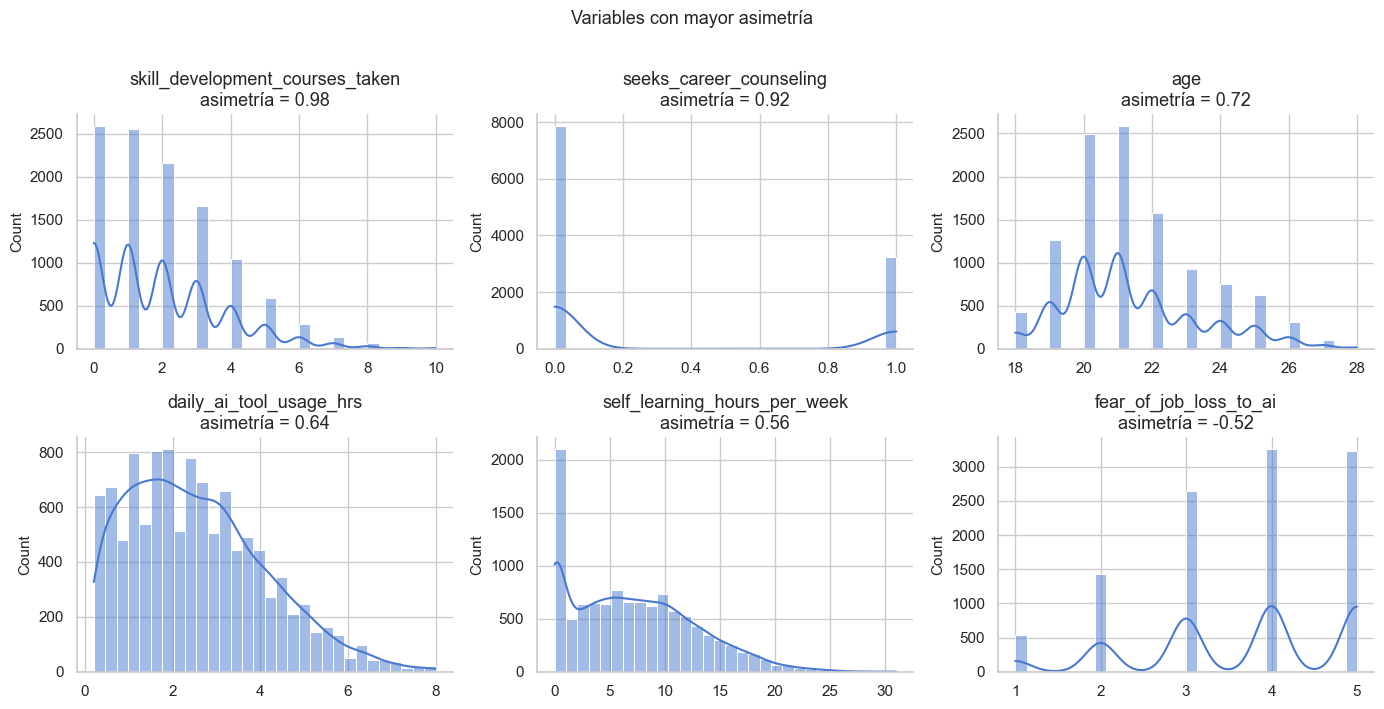

In [10]:
top_skewed = shape_df.reindex(
    shape_df["Asimetría"].abs().sort_values(ascending=False).index
).head(6)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(top_skewed.iterrows()):
    col = row["Variable"]
    sns.histplot(df[col].dropna(), bins=30, kde=True, color="#4878d0",
                 edgecolor="white", ax=axes[i])
    axes[i].set_title(f"{col}\nasimetría = {row['Asimetría']:.2f}")
    axes[i].set_xlabel("")
    sns.despine(ax=axes[i])

fig.suptitle("Variables con mayor asimetría", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_GRAFICOS_DIR / "panel_distribuciones_asimetricas.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Artefactos generados

Al finalizar la ejecución del notebook quedan disponibles los siguientes archivos.

In [11]:
artefactos = {
    "outputs/tablas/estadisticas_descriptivas.csv": "Estadísticas descriptivas de variables numéricas",
    "outputs/tablas/reporte_outliers.csv": "Límites IQR y conteo de valores atípicos por variable",
    "outputs/tablas/baja_variabilidad.csv": "Variables con baja variabilidad detectadas",
    "outputs/tablas/forma_distribuciones.csv": "Asimetría y curtosis por variable numérica",
    f"outputs/graficos/univar_<variable>.png  (×{len(num_cols)})": "Histograma + boxplot por variable numérica",
    f"outputs/graficos/bar_<variable>.png  (×{len(cat_cols)})": "Gráfico de barras por variable categórica",
    "outputs/graficos/resumen_outliers.png": "Porcentaje de outliers por variable",
    "outputs/graficos/panel_distribuciones_asimetricas.png": "Panel de las 6 distribuciones con mayor asimetría",
}

resumen = pd.DataFrame(artefactos.items(), columns=["Archivo", "Descripción"])
display(resumen)

,Archivo,Descripción
0,outputs/tablas/estadisticas_descriptivas.csv,Estadísticas descriptivas de variables numéricas
1,outputs/tablas/reporte_outliers.csv,Límites IQR y conteo de valores atípicos por v...
2,outputs/tablas/baja_variabilidad.csv,Variables con baja variabilidad detectadas
3,outputs/tablas/forma_distribuciones.csv,Asimetría y curtosis por variable numérica
4,outputs/graficos/univar_<variable>.png (×22),Histograma + boxplot por variable numérica
5,outputs/graficos/bar_<variable>.png (×7),Gráfico de barras por variable categórica
6,outputs/graficos/resumen_outliers.png,Porcentaje de outliers por variable
7,outputs/graficos/panel_distribuciones_asimetri...,Panel de las 6 distribuciones con mayor asimetría
